In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import SimpleITK as sitk


#PCA

In [21]:
from sklearn.decomposition import PCA
import torch
from skimage.transform import resize
import numpy as np

In [12]:
emb1 = torch.load('point_matching_process/emb1.pth')

In [16]:
pca = PCA()
d = emb1[1].numpy()
d2 = d.reshape((128, -1))

# Fit only on the non-air data
ct = sitk.ReadImage('data/PMCC_ReIrrad_L01/c1.nii.gz')
mask =  resize(sitk.GetArrayFromImage(ct), d.shape[2:], anti_aliasing=True, preserve_range=True)>0
pca.fit(d2[:, mask.ravel()].T)

d3 = pca.transform(d2.T)
d3 = d3.T
d4 = d3.reshape((128, ) + d.shape[2:])


In [17]:
arr = sitk.GetArrayFromImage(ct)

In [18]:
arr.shape

(190, 512, 512)

In [19]:
ct.GetSize(), ct.GetSpacing()

((512, 512, 190), (1.171875, 1.171875, 2.0))

In [22]:
np.array(ct.GetSize()) * np.array(ct.GetSpacing())

array([600., 600., 380.])

In [25]:
import matplotlib.pyplot as plt


In [60]:
arr2 = resize(arr, (95, 150, 150), preserve_range=True)
d5 = resize(d4[0], (95, 150, 150), preserve_range=True)

In [57]:
slice_id = 48
alpha = 0.5
cmap = 'coolwarm'

In [70]:
d.shape

(1, 128, 48, 19, 19)

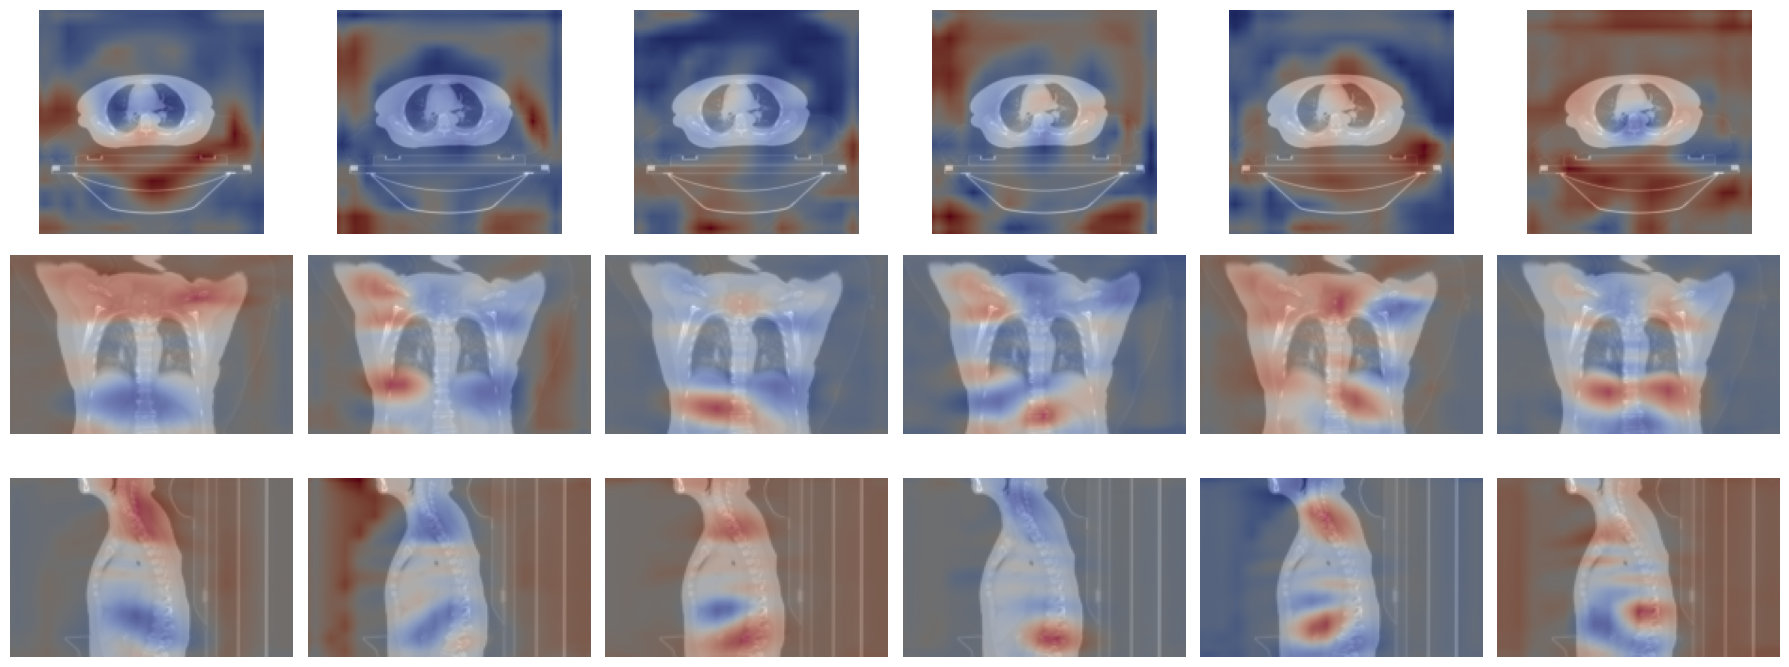

In [73]:
fig, ax = plt.subplots(3, 6, figsize=(18, 7))

for i in range(6):
  d5 = resize(d4[i], (95, 150, 150), preserve_range=True)

  ax[0, i].imshow(arr2[48], cmap='gray')
  ax[0, i].imshow(d5[48], cmap=cmap, alpha=alpha)

  ax[1, i].imshow(arr2[::-1,75,:], cmap='gray')
  ax[1, i].imshow(d5[::-1,75,:], cmap=cmap, alpha=alpha)

  ax[2, i].imshow(arr2[::-1,:,75], cmap='gray')
  ax[2, i].imshow(d5[::-1,:,75], cmap=cmap, alpha=alpha)

for a in ax.ravel(): a.axis('off')
plt.tight_layout()

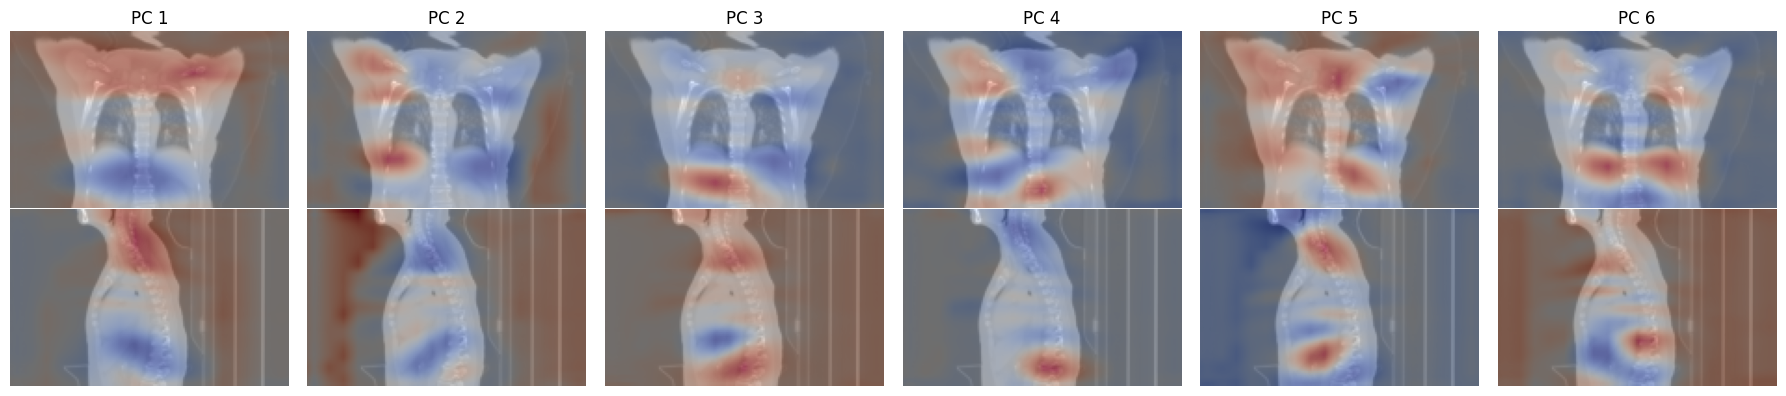

In [76]:
fig, ax = plt.subplots(2, 6, figsize=(18, 4))

for i in range(6):
  d5 = resize(d4[i], (95, 150, 150), preserve_range=True)

  ax[0, i].imshow(arr2[::-1,75,:], cmap='gray')
  ax[0, i].imshow(d5[::-1,75,:], cmap=cmap, alpha=alpha)
  ax[0, i].set_title(f'PC {i+1}')

  ax[1, i].imshow(arr2[::-1,:,75], cmap='gray')
  ax[1, i].imshow(d5[::-1,:,75], cmap=cmap, alpha=alpha)

for a in ax.ravel(): a.axis('off')

plt.tight_layout()

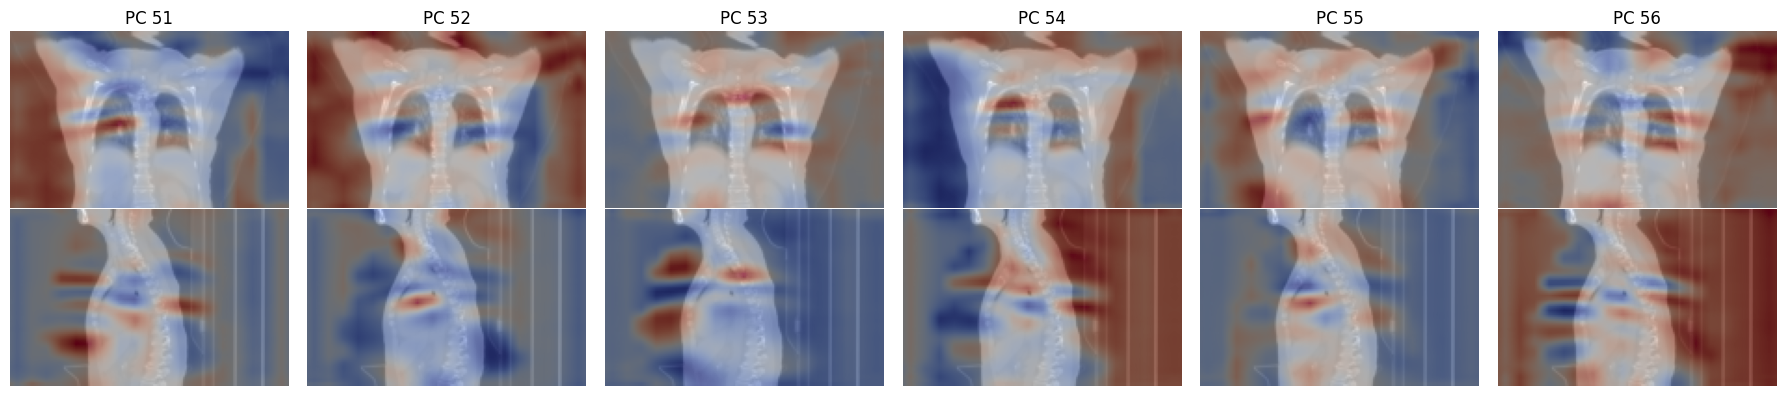

In [81]:
fig, ax = plt.subplots(2, 6, figsize=(18, 4))
start = 50

for i in range(6):
  d5 = resize(d4[start+i], (95, 150, 150), preserve_range=True)

  ax[0, i].imshow(arr2[::-1,75,:], cmap='gray')
  ax[0, i].imshow(d5[::-1,75,:], cmap=cmap, alpha=alpha)
  ax[0, i].set_title(f'PC {start+i+1}')

  ax[1, i].imshow(arr2[::-1,:,75], cmap='gray')
  ax[1, i].imshow(d5[::-1,:,75], cmap=cmap, alpha=alpha)

for a in ax.ravel(): a.axis('off')

plt.tight_layout()

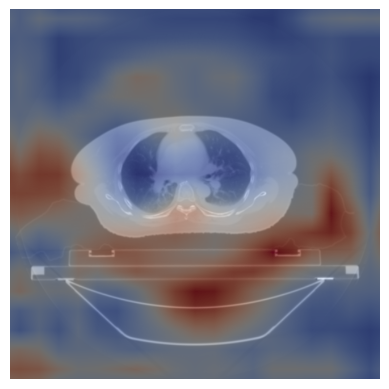

In [41]:
plt.imshow(arr2[slice_id], cmap='gray')
plt.imshow(d5[slice_id], cmap=cmap, alpha=alpha)
plt.axis('off')
plt.show()

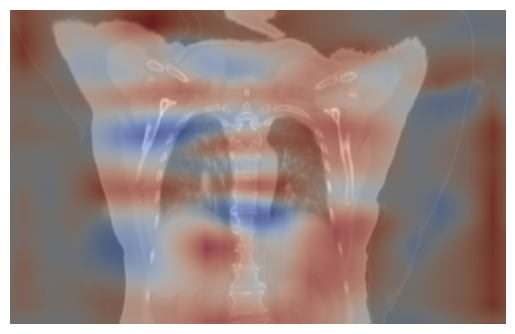

In [50]:
plt.imshow(arr2[::-1,300,:], cmap='gray')
plt.imshow(d5[::-1,300,:], cmap=cmap, alpha=alpha)
plt.axis('off')
plt.show()

## Raw channels

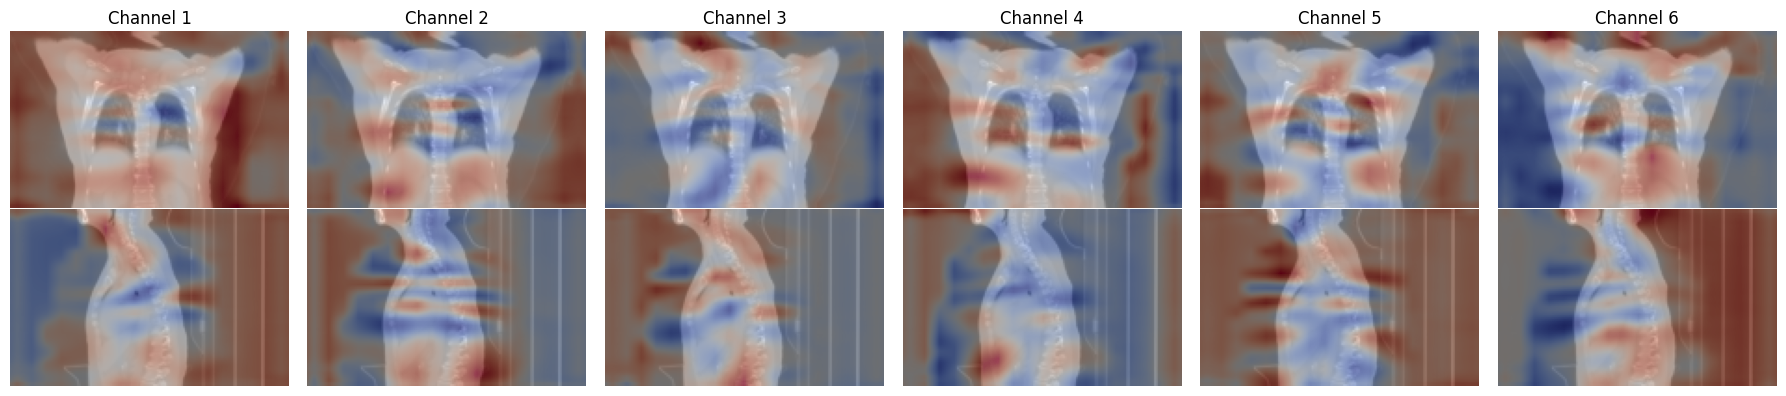

In [83]:
fig, ax = plt.subplots(2, 6, figsize=(18, 4))

for i in range(6):
  d5 = resize(d[0][i], (95, 150, 150), preserve_range=True)

  ax[0, i].imshow(arr2[::-1,75,:], cmap='gray')
  ax[0, i].imshow(d5[::-1,75,:], cmap=cmap, alpha=alpha)
  ax[0, i].set_title(f'Channel {i+1}')

  ax[1, i].imshow(arr2[::-1,:,75], cmap='gray')
  ax[1, i].imshow(d5[::-1,:,75], cmap=cmap, alpha=alpha)

for a in ax.ravel(): a.axis('off')

plt.tight_layout()

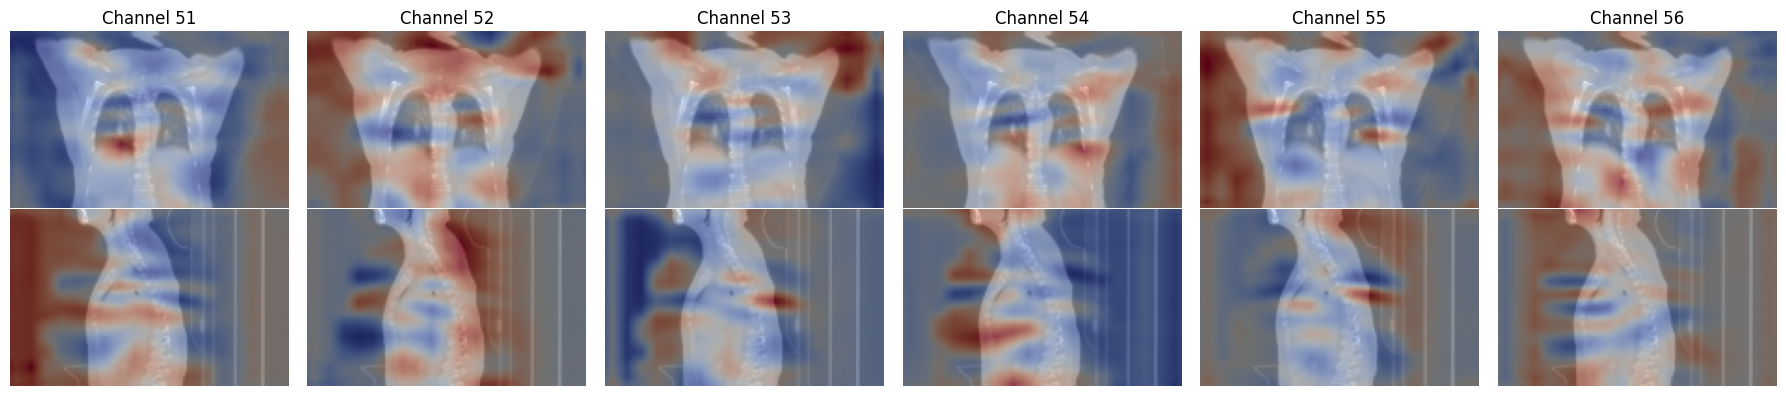

In [84]:
fig, ax = plt.subplots(2, 6, figsize=(18, 4))
start = 50

for i in range(6):
  d5 = resize(d[0][start+i], (95, 150, 150), preserve_range=True)

  ax[0, i].imshow(arr2[::-1,75,:], cmap='gray')
  ax[0, i].imshow(d5[::-1,75,:], cmap=cmap, alpha=alpha)
  ax[0, i].set_title(f'Channel {start+i+1}')

  ax[1, i].imshow(arr2[::-1,:,75], cmap='gray')
  ax[1, i].imshow(d5[::-1,:,75], cmap=cmap, alpha=alpha)

for a in ax.ravel(): a.axis('off')

plt.tight_layout()